<a href="https://colab.research.google.com/github/prasanna-venkatesh-m/Analytics-Forecast/blob/main/XGBoost_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor
import re
import matplotlib.pyplot as plt

In [62]:
df = pd.read_csv('/content/lag_data.csv')
df.columns = [re.sub(r'[^\w\s]', '', col).replace(' ', '_') for col in df.columns]
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

In [63]:
df = df.drop(columns=['Unnamed_0'])

In [64]:
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter
df['year'] = df['Date'].dt.year

In [65]:
targets = [
    'CountofGroup', 'CountofClientName', 'CountofAccountID',
    'CountofCreditOfficerID', 'SumofPrincipalOutstanding', 'SumofInterestOutstanding',
    'SumofTotalPrincipalOverdue', 'SumofTotalInterestOverdue', 'SumofTotalPAR'
]

for col in targets:
    df[f'{col}_lag1'] = df.groupby('BranchID')[col].shift(1)

target_lags = [f'{col}_lag1' for col in targets]
historical_csv_lags = [col for col in df.columns if '_day_lag' in col] # e.g., 7day_lag
time_features = ['month', 'quarter', 'year', 'BranchID']

features = target_lags + historical_csv_lags + time_features

df = df.dropna(subset=target_lags)

In [66]:
df

,BranchID,Date,CountofGroup,CountofClientName,CountofAccountID,CountofCreditOfficerID,SumofPrincipalOutstanding,SumofInterestOutstanding,SumofTotalPrincipalOverdue,SumofTotalInterestOverdue,...,year,CountofGroup_lag1,CountofClientName_lag1,CountofAccountID_lag1,CountofCreditOfficerID_lag1,SumofPrincipalOutstanding_lag1,SumofInterestOutstanding_lag1,SumofTotalPrincipalOverdue_lag1,SumofTotalInterestOverdue_lag1,SumofTotalPAR_lag1
152,1,2023-04-01,238,238,238,238,2884071,298519,2836866,296178,...,2023,238.0,238.0,238.0,238.0,2884071.0,298519.0,2836866.0,296178.0,2884071.0
153,2,2023-04-01,269,269,269,269,3342578,396290,3294740,394320,...,2023,269.0,269.0,269.0,269.0,3342578.0,396290.0,3294740.0,394320.0,3342578.0
154,3,2023-04-01,149,149,149,149,1989393,209196,1822503,200022,...,2023,149.0,149.0,149.0,149.0,1989393.0,209196.0,1822503.0,200022.0,1989393.0
155,4,2023-04-01,321,321,321,321,3705798,454072,3698023,453812,...,2023,321.0,321.0,321.0,321.0,3705798.0,454072.0,3698023.0,453812.0,3705798.0
156,5,2023-04-01,89,89,89,89,1053737,108325,972575,102512,...,2023,89.0,89.0,89.0,89.0,1053737.0,108325.0,972575.0,102512.0,1053737.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
172971,148,2026-05-11,564,544,564,564,12819001,2286291,7313613,1269273,...,2026,549.0,529.0,549.0,549.0,12557959.0,2242320.0,7294000.0,1267459.0,12557959.0
172972,149,2026-05-11,434,425,434,434,8335407,1317079,5608698,841014,...,2026,438.0,429.0,438.0,438.0,8545228.0,1368322.0,5607690.0,844323.0,8545228.0
172973,150,2026-05-11,242,226,242,242,4246027,527290,3096316,362184,...,2026,243.0,227.0,243.0,243.0,4335995.0,553305.0,3098598.0,364499.0,4335995.0
172974,152,2026-05-11,2,2,2,2,200000,61532,6068,4808,...,2026,2.0,2.0,2.0,2.0,200000.0,61532.0,6068.0,4808.0,200000.0


In [67]:
print(df.columns.tolist())

['BranchID', 'Date', 'CountofGroup', 'CountofClientName', 'CountofAccountID', 'CountofCreditOfficerID', 'SumofPrincipalOutstanding', 'SumofInterestOutstanding', 'SumofTotalPrincipalOverdue', 'SumofTotalInterestOverdue', 'SumofTotalPAR', 'CountofGroup_1day_lag', 'CountofClientName_1day_lag', 'CountofAccountID_1day_lag', 'CountofCreditOfficerID_1day_lag', 'SumofPrincipalOutstanding_1day_lag', 'SumofInterestOutstanding_1day_lag', 'SumofTotalPrincipalOverdue_1day_lag', 'SumofTotalInterestOverdue_1day_lag', 'SumofTotalPAR_1day_lag', 'CountofGroup_7day_lag', 'CountofClientName_7day_lag', 'CountofAccountID_7day_lag', 'CountofCreditOfficerID_7day_lag', 'SumofPrincipalOutstanding_7day_lag', 'SumofInterestOutstanding_7day_lag', 'SumofTotalPrincipalOverdue_7day_lag', 'SumofTotalInterestOverdue_7day_lag', 'SumofTotalPAR_7day_lag', 'CountofGroup_15day_lag', 'CountofClientName_15day_lag', 'CountofAccountID_15day_lag', 'CountofCreditOfficerID_15day_lag', 'SumofPrincipalOutstanding_15day_lag', 'SumofI

In [68]:
df_logged = df.copy()

for col in targets:
    df_logged[col] = np.log1p(df_logged[col])

# Log transform the lags as well
for col in target_lags:
    df_logged[col] = np.log1p(df_logged[col])

for col in targets:
    df_logged[f'{col}_delta'] = df_logged[col] - df_logged[f'{col}_lag1']

# Update your target list to use these new delta columns
delta_targets = [f'{col}_delta' for col in targets]

In [69]:
train_df = df_logged[df_logged['Date'] < '2026-04-01'].copy()
test_df = df_logged[df_logged['Date'] >= '2026-04-01'].copy()

X_train, y_train = train_df[features], train_df[delta_targets] # Use delta_targets here
X_test, y_test = test_df[features], test_df[delta_targets]

In [70]:
print("Training XGBoost Multi-Output Model...")
# Use 'hist' tree_method for much faster training with large datasets
xgb_regressor = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    objective='reg:squarederror',
    random_state=42
)

model = MultiOutputRegressor(xgb_regressor)
model.fit(X_train, y_train)

Training XGBoost Multi-Output Model...


MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [71]:
encoded_delta_preds = model.predict(X_test)

yesterday_logs = X_test[[f'{col}_lag1' for col in targets]].values
reconstructed_logs = yesterday_logs + encoded_delta_preds

decoded_preds = np.expm1(reconstructed_logs)

decoded_actuals = np.expm1(test_df[targets].values)

In [72]:
branch_to_view = 1
# Find the rows in the test set belonging to this branch
branch_mask = (test_df['BranchID'] == branch_to_view)
branch_indices = test_df.index[branch_mask]

In [73]:
branch_pos = np.where(branch_mask)[0]
branch_actuals = decoded_actuals[branch_pos]
branch_preds = decoded_preds[branch_pos]
branch_dates = df.loc[branch_indices, 'Date']

# Sort by date for a clean line plot
plot_df = pd.DataFrame({
    'Date': branch_dates,
    'Actual': branch_actuals[:, 8],
    'Predicted': branch_preds[:, 8]
}).sort_values('Date')

In [74]:
plot_df

,Date,Actual,Predicted
166744,2026-04-01,8745379.0,8.739401e+06
166896,2026-04-02,8776797.0,8.774749e+06
167048,2026-04-03,8703688.0,8.806272e+06
167200,2026-04-04,8964745.0,8.735180e+06
167352,2026-04-05,8964745.0,8.991176e+06
167504,2026-04-06,8916022.0,8.991176e+06
167656,2026-04-07,8975807.0,8.942309e+06
167808,2026-04-08,7475491.0,9.002270e+06
167960,2026-04-09,7240765.0,7.525353e+06
168112,2026-04-10,7033136.0,7.333101e+06


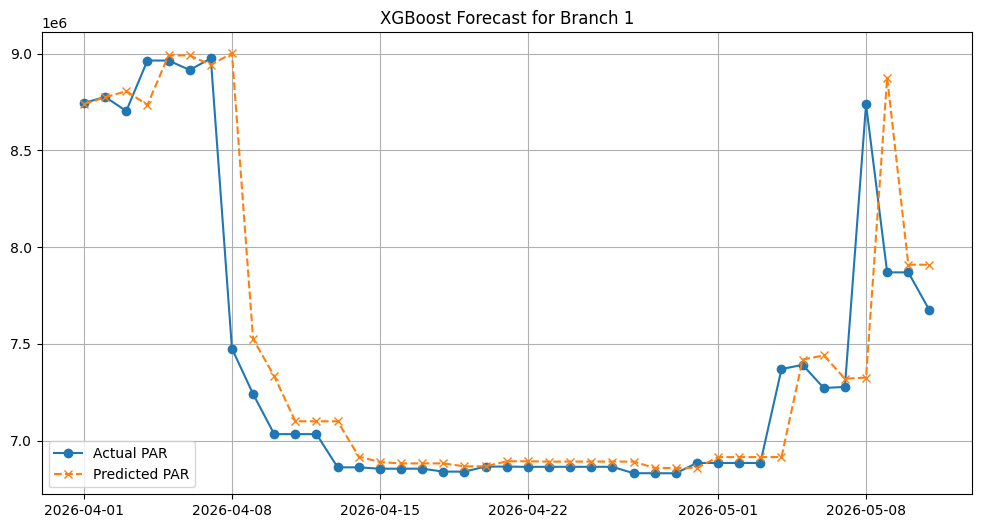

In [75]:
plt.figure(figsize=(12, 6))
plt.plot(plot_df['Date'], plot_df['Actual'], label='Actual PAR', marker='o')
plt.plot(plot_df['Date'], plot_df['Predicted'], label='Predicted PAR', marker='x',linestyle='--')
plt.title(f"XGBoost Forecast for Branch {branch_to_view}")
plt.legend()
plt.grid(True)
plt.show()